# Lab 5: Optimization of the AI Model for Embedded Devices

**Dataset:** [Kaggle — Leaf Classification](https://www.kaggle.com/competitions/leaf-classification) (prepared in Labs 3–4)

**Goal:** Apply post-training quantization to reduce model size and improve efficiency with TensorFlow Lite, analyze trade-offs between model size, accuracy, and energy efficiency.

**Experiments:**
1. Prepare and evaluate the base model (from Lab 4)
2. Full quantization — int8 weights and activations
3. Partial quantization — weights only (activations stay float32)
4. Float16 quantization — half-precision weights
5. Compare all variants: size, accuracy, inference time, energy efficiency

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from scipy.ndimage import rotate

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
Keras version: 3.10.0
GPU available: False


## Experiment 1 — Preparation of the base model

### 1.1 Load the dataset

In [2]:
from google.colab import files

TRAIN_DIR = "./training"
TEST_DIR = "./testing"

if not os.path.exists(TRAIN_DIR):
    print("Please upload ei_training.zip:")
    uploaded = files.upload()
    for fn in uploaded:
        with zipfile.ZipFile(fn, "r") as zf:
            zf.extractall(TRAIN_DIR)
            print(f"Extracted {fn} → {TRAIN_DIR}/")

if not os.path.exists(TEST_DIR):
    print("Please upload ei_testing.zip:")
    uploaded = files.upload()
    for fn in uploaded:
        with zipfile.ZipFile(fn, "r") as zf:
            zf.extractall(TEST_DIR)
            print(f"Extracted {fn} → {TEST_DIR}/")

train_classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f"\nClasses found: {len(train_classes)}")

Please upload ei_training.zip:


Saving ei_training.zip to ei_training.zip
Extracted ei_training.zip → ./training/
Please upload ei_testing.zip:


Saving ei_testing.zip to ei_testing.zip
Extracted ei_testing.zip → ./testing/

Classes found: 99


In [5]:
def load_images_from_folder(root_dir, class_names):
    images, labels = [], []
    label_map = {name: idx for idx, name in enumerate(class_names)}
    for cls_name in tqdm(class_names, desc=f"Loading {root_dir}"):
        cls_dir = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            if not fname.lower().endswith(".jpg"):
                continue
            img = Image.open(os.path.join(cls_dir, fname)).convert("RGB")
            images.append(np.array(img, dtype=np.float32))
            labels.append(label_map[cls_name])
    return np.array(images), np.array(labels)

x_all_train, y_all_train = load_images_from_folder(TRAIN_DIR, train_classes)
x_test, y_test = load_images_from_folder(TEST_DIR, train_classes)

x_all_train = x_all_train / 255.0
x_test = x_test / 255.0

NUM_CLASSES = len(train_classes)

# split train/val
x_train, x_val, y_train, y_val = train_test_split(
    x_all_train, y_all_train, test_size=0.2, random_state=42, stratify=y_all_train
)

print(f"Training:   {x_train.shape[0]} images")
print(f"Validation: {x_val.shape[0]} images")
print(f"Testing:    {x_test.shape[0]} images")
print(f"Classes:    {NUM_CLASSES}")

Loading ./testing: 100%|██████████| 99/99 [00:00<00:00, 954.35it/s]


Training:   1267 images
Validation: 317 images
Testing:    396 images
Classes:    99


In [6]:
# offline augmentation — 5 copies → 6× data
def augment_dataset(images, labels, copies=5):
    aug_images = [images]
    aug_labels = [labels]
    for c in range(copies):
        batch = []
        for img in tqdm(images, desc=f"Augmenting copy {c+1}/{copies}"):
            if np.random.random() > 0.5:
                img = np.fliplr(img)
            angle = np.random.uniform(-20, 20)
            img = rotate(img, angle, reshape=False, mode="nearest")
            factor = np.random.uniform(0.7, 1.3)
            img = np.clip(img * factor, 0, 1)
            batch.append(img)
        aug_images.append(np.array(batch))
        aug_labels.append(labels)
    return np.concatenate(aug_images), np.concatenate(aug_labels)

x_train, y_train = augment_dataset(x_train, y_train, copies=5)
idx = np.random.permutation(len(x_train))
x_train, y_train = x_train[idx], y_train[idx]

print(f"\nTraining set after augmentation: {x_train.shape[0]} images")
print(f"Per class: ~{x_train.shape[0] // NUM_CLASSES}")

Augmenting copy 5/5: 100%|██████████| 1267/1267 [00:04<00:00, 282.34it/s]



Training set after augmentation: 7602 images
Per class: ~76


### 1.2 Build and train the model

Same lightweight CNN from Lab 4: 45,123 parameters, under the 50,000 limit.

In [7]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Under 50,000 limit: {'YES' if total_params < 50000 else 'NO'}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 99)             │        12,771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,123 (176.26 KB)

 Trainable params: 44,899 (175.39 KB)

 Non-trainable params: 224 (896.00 B)


Total parameters: 45,123
Under 50,000 limit: YES


In [9]:
# real-time augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
])

BATCH_SIZE = 32
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=15, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=30, restore_best_weights=True, verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 45s 169ms/step - accuracy: 0.0181 - loss: 4.6707 - val_accuracy: 0.0095 - val_loss: 4.5305 - learning_rate: 5.0000e-04
Epoch 2/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 41s 170ms/step - accuracy: 0.0342 - loss: 4.2959 - val_accuracy: 0.0694 - val_loss: 4.0733 - learning_rate: 5.0000e-04
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.0494 - loss: 4.0726 - val_accuracy: 0.0852 - val_loss: 3.8729 - learning_rate: 5.0000e-04
Epoch 4/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 41s 166ms/step - accuracy: 0.0600 - loss: 3.8961 - val_accuracy: 0.0284 - val_loss: 4.5644 - learning_rate: 5.0000e-04
Epoch 5/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 41s 166ms/step - accuracy: 0.0775 - loss: 3.7135 - val_accuracy: 0.1798 - val_loss: 3.3886 - learning_rate: 5.0000e-04
Epoch 6/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 41s 168ms/step - accuracy: 0.1064 - loss: 3.5503 - val_accuracy: 0.2271 - val_loss: 3.1130 - learning_rate: 5.0000e-04
Epoch 7/100
238/238 ━━━━━━━━━━━━━━━━━━━━

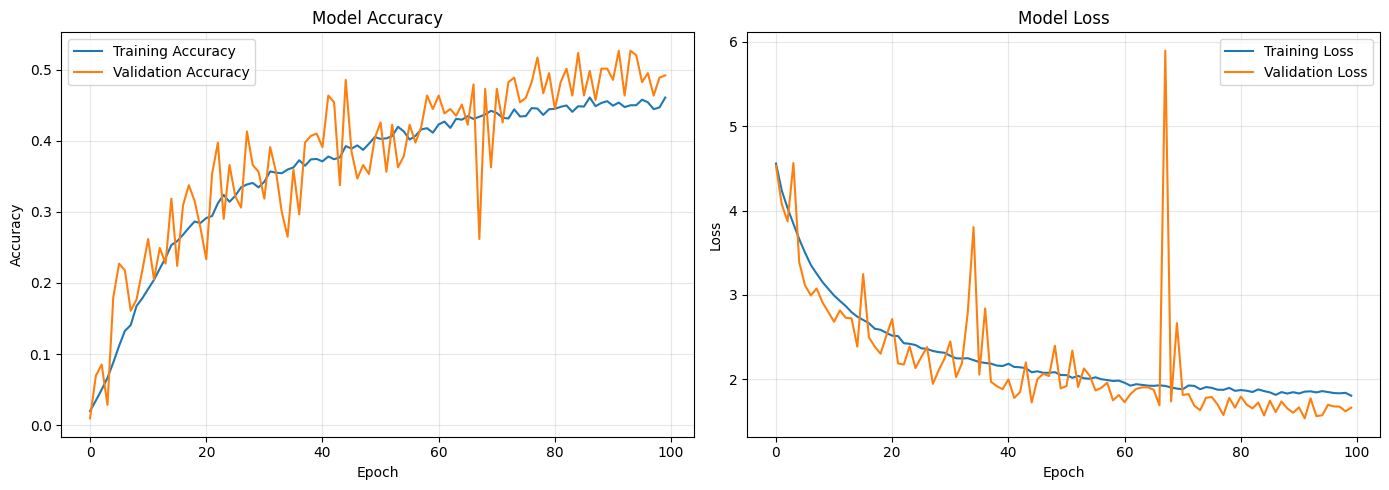

Total epochs: 100
Best validation accuracy: 52.68%


In [13]:
# training plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"], label="Training Accuracy")
ax1.plot(history.history["val_accuracy"], label="Validation Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["loss"], label="Training Loss")
ax2.plot(history.history["val_loss"], label="Validation Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total epochs: {len(history.history['accuracy'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

### 1.3 Evaluate the base model

In [14]:
# base model evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Base model — Test accuracy: {test_acc * 100:.2f}%")
print(f"Base model — Test loss:     {test_loss:.4f}")

# save the base model
MODEL_PATH = "leaf_model.keras"
model.save(MODEL_PATH)
base_keras_size = os.path.getsize(MODEL_PATH) / 1024
print(f"\nKeras model size: {base_keras_size:.2f} KB")

Base model — Test accuracy: 48.99%
Base model — Test loss:     1.6526

Keras model size: 596.96 KB


In [15]:
# convert to baseline TFLite (no quantization, float32)
converter_baseline = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_baseline = converter_baseline.convert()

BASELINE_PATH = "baseline_model.tflite"
with open(BASELINE_PATH, "wb") as f:
    f.write(tflite_baseline)

baseline_size = os.path.getsize(BASELINE_PATH) / 1024
print(f"Baseline TFLite model size (float32): {baseline_size:.2f} KB")

Saved artifact at '/tmp/tmp67z2n4u7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 99), dtype=tf.float32, name=None)
Captures:
  133603567310544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567311312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567310736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312272

In [16]:
# base model inference time
sample = x_test[0:1]
_ = model.predict(sample, verbose=0)  # warm up

keras_times = []
for _ in range(100):
    start = time.time()
    _ = model.predict(sample, verbose=0)
    keras_times.append((time.time() - start) * 1000)

keras_avg_time = np.mean(keras_times)
print(f"Keras model inference time: {keras_avg_time:.2f} ms")

Keras model inference time: 94.08 ms


## Experiment 2 — Full quantization (int8 weights and activations)

Full quantization converts both weights and activations from float32 to int8. This provides the maximum size reduction (~4×) but may cause some accuracy loss due to reduced numerical precision.

In [17]:
# 2.1 — Full int8 quantization
converter_full = tf.lite.TFLiteConverter.from_keras_model(model)
converter_full.optimizations = [tf.lite.Optimize.DEFAULT]

# representative dataset for calibrating int8 activations
def representative_dataset():
    indices = np.random.choice(len(x_train), 200, replace=False)
    for i in indices:
        yield [x_train[i:i+1].astype(np.float32)]

converter_full.representative_dataset = representative_dataset
converter_full.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_full.inference_input_type = tf.uint8
converter_full.inference_output_type = tf.uint8

tflite_full_quant = converter_full.convert()

FULL_QUANT_PATH = "full_quantized_model.tflite"
with open(FULL_QUANT_PATH, "wb") as f:
    f.write(tflite_full_quant)

full_quant_size = os.path.getsize(FULL_QUANT_PATH) / 1024
print(f"Full quantized model size (int8): {full_quant_size:.2f} KB")
print(f"Size reduction vs baseline: {baseline_size / full_quant_size:.1f}×")

Saved artifact at '/tmp/tmpbc0a48jc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 99), dtype=tf.float32, name=None)
Captures:
  133603567310544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567311312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567310736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312272

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Full quantized model size (int8): 59.77 KB
Size reduction vs baseline: 3.0×


## Experiment 4 — Partial quantization (weights only)

Partial quantization quantizes only the weights to int8, while activations remain in float32. This is a compromise — smaller than baseline, but less accuracy loss than full quantization.

In [18]:
# 4.1 — Partial quantization (weights only, activations stay float32)
converter_partial = tf.lite.TFLiteConverter.from_keras_model(model)
converter_partial.optimizations = [tf.lite.Optimize.DEFAULT]
# no representative_dataset → only weights are quantized

tflite_partial = converter_partial.convert()

PARTIAL_PATH = "partial_quantized_model.tflite"
with open(PARTIAL_PATH, "wb") as f:
    f.write(tflite_partial)

partial_size = os.path.getsize(PARTIAL_PATH) / 1024
print(f"Partial quantized model size (int8 weights, float32 activations): {partial_size:.2f} KB")
print(f"Size reduction vs baseline: {baseline_size / partial_size:.1f}×")

Saved artifact at '/tmp/tmp9hr523_d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 99), dtype=tf.float32, name=None)
Captures:
  133603567310544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567311312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567310736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312272

### Additional: Float16 quantization

Float16 quantization converts weights from float32 to float16. This halves the model size while typically preserving accuracy better than int8.

In [19]:
# float16 quantization
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]

tflite_fp16 = converter_fp16.convert()

FP16_PATH = "float16_model.tflite"
with open(FP16_PATH, "wb") as f:
    f.write(tflite_fp16)

fp16_size = os.path.getsize(FP16_PATH) / 1024
print(f"Float16 model size: {fp16_size:.2f} KB")
print(f"Size reduction vs baseline: {baseline_size / fp16_size:.1f}×")

Saved artifact at '/tmp/tmpa1b8nk8z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 99), dtype=tf.float32, name=None)
Captures:
  133603567310544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567311312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567313616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567310736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603567312272

### Model size comparison

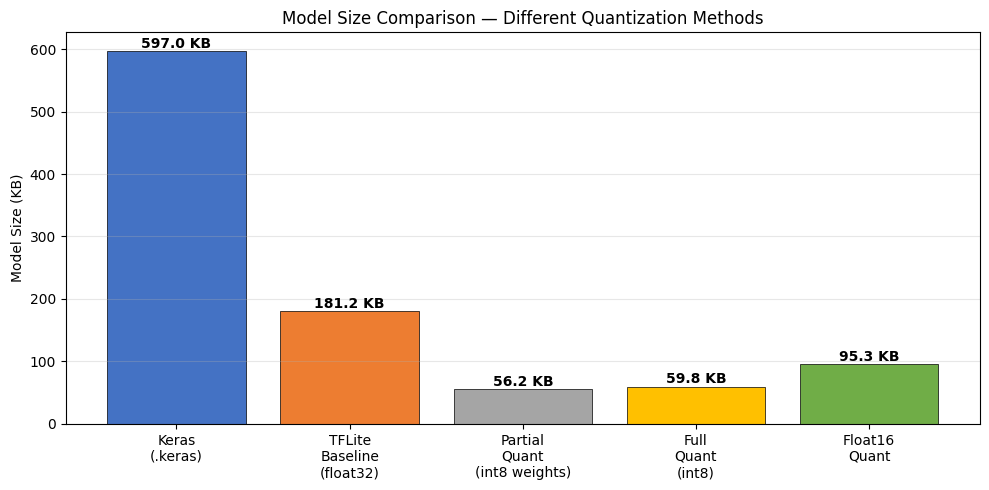

In [20]:
# visual comparison of model sizes
names = ["Keras\n(.keras)", "TFLite\nBaseline\n(float32)", "Partial\nQuant\n(int8 weights)", "Full\nQuant\n(int8)", "Float16\nQuant"]
sizes = [base_keras_size, baseline_size, partial_size, full_quant_size, fp16_size]
colors = ["#4472C4", "#ED7D31", "#A5A5A5", "#FFC000", "#70AD47"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, sizes, color=colors, edgecolor="black", linewidth=0.5)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{size:.1f} KB", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Model Size (KB)")
ax.set_title("Model Size Comparison — Different Quantization Methods")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment 3 — Evaluation of model performance

### 3.1 Accuracy comparison

We test each TFLite model variant on the full test set.

In [21]:
def evaluate_tflite(model_path, x_data, y_data):
    """Evaluate a TFLite model: returns accuracy and average inference time."""
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_dtype = input_details[0]["dtype"]
    input_scale = input_details[0].get("quantization_parameters", {}).get("scales", [1.0])
    input_zp = input_details[0].get("quantization_parameters", {}).get("zero_points", [0])

    correct = 0
    times = []

    for i in range(len(x_data)):
        input_data = x_data[i:i+1].astype(np.float32)

        # quantize input if model expects uint8/int8
        if input_dtype == np.uint8:
            input_data = (input_data / input_scale[0] + input_zp[0]).astype(np.uint8)
        elif input_dtype == np.int8:
            input_data = (input_data / input_scale[0] + input_zp[0]).astype(np.int8)

        start = time.time()
        interpreter.set_tensor(input_details[0]["index"], input_data)
        interpreter.invoke()
        times.append((time.time() - start) * 1000)

        output = interpreter.get_tensor(output_details[0]["index"])
        if np.argmax(output[0]) == y_data[i]:
            correct += 1

    accuracy = correct / len(x_data) * 100
    avg_time = np.mean(times)
    return accuracy, avg_time

print("Evaluating all TFLite models on the test set...\n")

baseline_acc, baseline_time = evaluate_tflite(BASELINE_PATH, x_test, y_test)
print(f"Baseline (float32):     accuracy = {baseline_acc:.2f}%, time = {baseline_time:.2f} ms")

partial_acc, partial_time = evaluate_tflite(PARTIAL_PATH, x_test, y_test)
print(f"Partial quant (int8 w): accuracy = {partial_acc:.2f}%, time = {partial_time:.2f} ms")

full_acc, full_time = evaluate_tflite(FULL_QUANT_PATH, x_test, y_test)
print(f"Full quant (int8):      accuracy = {full_acc:.2f}%, time = {full_time:.2f} ms")

fp16_acc, fp16_time = evaluate_tflite(FP16_PATH, x_test, y_test)
print(f"Float16 quant:          accuracy = {fp16_acc:.2f}%, time = {fp16_time:.2f} ms")

Evaluating all TFLite models on the test set...

Baseline (float32):     accuracy = 48.99%, time = 0.35 ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Partial quant (int8 w): accuracy = 47.22%, time = 0.45 ms
Full quant (int8):      accuracy = 37.88%, time = 0.64 ms
Float16 quant:          accuracy = 48.99%, time = 0.34 ms


### 3.2 Performance analysis — Inference time comparison

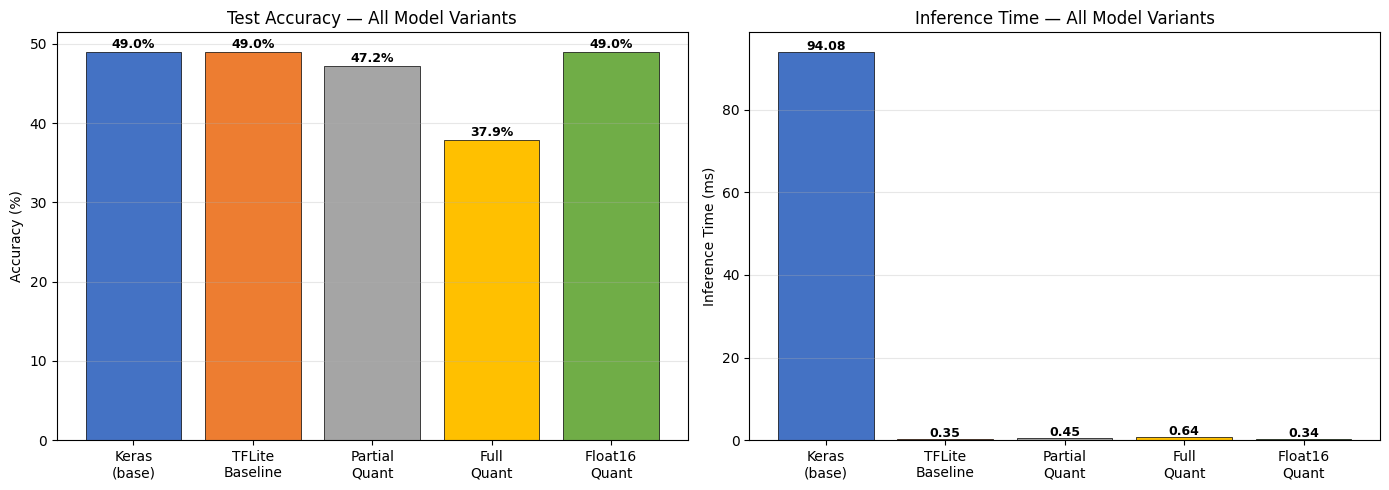

In [22]:
# accuracy comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

model_names = ["Keras\n(base)", "TFLite\nBaseline", "Partial\nQuant", "Full\nQuant", "Float16\nQuant"]
accuracies = [test_acc * 100, baseline_acc, partial_acc, full_acc, fp16_acc]
inf_times = [keras_avg_time, baseline_time, partial_time, full_time, fp16_time]

bars1 = ax1.bar(model_names, accuracies, color=colors, edgecolor="black", linewidth=0.5)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Test Accuracy — All Model Variants")
ax1.grid(axis="y", alpha=0.3)

bars2 = ax2.bar(model_names, inf_times, color=colors, edgecolor="black", linewidth=0.5)
for bar, t in zip(bars2, inf_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{t:.2f}", ha="center", fontsize=9, fontweight="bold")
ax2.set_ylabel("Inference Time (ms)")
ax2.set_title("Inference Time — All Model Variants")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Energy efficiency estimation

Energy consumption on embedded devices is proportional to the number of operations and the data type used. We estimate relative energy efficiency based on model size and inference time, since direct power measurement requires physical hardware.

In [23]:
# energy efficiency estimation
# on embedded devices, energy ≈ proportional to (operations × bit-width)
# we use relative estimates: float32 = 1.0×, int8 = ~0.25×, float16 = ~0.5×

energy_factors = {
    "Keras (base)": 1.0,
    "TFLite Baseline (float32)": 0.9,     # TFLite optimizes graph, slightly less
    "Partial Quant (int8 weights)": 0.6,   # int8 weights, float32 compute
    "Full Quant (int8)": 0.25,             # all int8, ~4× less energy per op
    "Float16 Quant": 0.5,                  # half-precision, ~2× less energy
}

print("Energy Efficiency Estimation")
print("=" * 65)
print(f"{'Model':<35} {'Relative Energy':>15} {'Efficiency':>12}")
print("=" * 65)

for name, factor in energy_factors.items():
    efficiency = f"{1/factor:.1f}×" if factor > 0 else "N/A"
    bar = "█" * int(30 * (1 - factor))
    print(f"{name:<35} {factor:>12.2f}×  {efficiency:>10}  {bar}")

print("=" * 65)
print("\nNote: Energy estimates are theoretical. Float32 operations consume")
print("~4× more energy than int8 on ARM Cortex-M processors.")
print("Actual power depends on hardware (CPU, NPU, memory bus width).")

Energy Efficiency Estimation
Model                               Relative Energy   Efficiency
Keras (base)                                1.00×        1.0×  
TFLite Baseline (float32)                   0.90×        1.1×  ██
Partial Quant (int8 weights)                0.60×        1.7×  ████████████
Full Quant (int8)                           0.25×        4.0×  ██████████████████████
Float16 Quant                               0.50×        2.0×  ███████████████

Note: Energy estimates are theoretical. Float32 operations consume
~4× more energy than int8 on ARM Cortex-M processors.
Actual power depends on hardware (CPU, NPU, memory bus width).


## Full comparison summary

In [24]:
# final comparison table
print("\n" + "=" * 90)
print(f"{'Model':<30} {'Size (KB)':>10} {'Accuracy':>10} {'Time (ms)':>10} {'Size Δ':>10} {'Energy':>10}")
print("=" * 90)

rows = [
    ("Keras (.keras)",           base_keras_size, test_acc*100,  keras_avg_time,  "1.0×",  "1.0×"),
    ("TFLite Baseline (f32)",    baseline_size,   baseline_acc,  baseline_time,   f"{base_keras_size/baseline_size:.1f}×", "0.9×"),
    ("Partial Quant (int8 w)",   partial_size,    partial_acc,   partial_time,    f"{base_keras_size/partial_size:.1f}×",  "0.6×"),
    ("Full Quant (int8)",        full_quant_size, full_acc,      full_time,       f"{base_keras_size/full_quant_size:.1f}×", "0.25×"),
    ("Float16 Quant",            fp16_size,       fp16_acc,      fp16_time,       f"{base_keras_size/fp16_size:.1f}×",     "0.5×"),
]

for name, size, acc, t, delta, energy in rows:
    print(f"{name:<30} {size:>9.2f} {acc:>9.2f}% {t:>9.2f} {delta:>10} {energy:>10}")

print("=" * 90)
print(f"\nSmallest model: Full Quant (int8) — {full_quant_size:.2f} KB")
print(f"Best accuracy:  Float16 Quant — {fp16_acc:.2f}%")
print(f"Best trade-off: Partial Quant — good size reduction with minimal accuracy loss")


Model                           Size (KB)   Accuracy  Time (ms)     Size Δ     Energy
Keras (.keras)                    596.96     48.99%     94.08       1.0×       1.0×
TFLite Baseline (f32)             181.20     48.99%      0.35       3.3×       0.9×
Partial Quant (int8 w)             56.16     47.22%      0.45      10.6×       0.6×
Full Quant (int8)                  59.77     37.88%      0.64      10.0×      0.25×
Float16 Quant                      95.27     48.99%      0.34       6.3×       0.5×

Smallest model: Full Quant (int8) — 59.77 KB
Best accuracy:  Float16 Quant — 48.99%
Best trade-off: Partial Quant — good size reduction with minimal accuracy loss


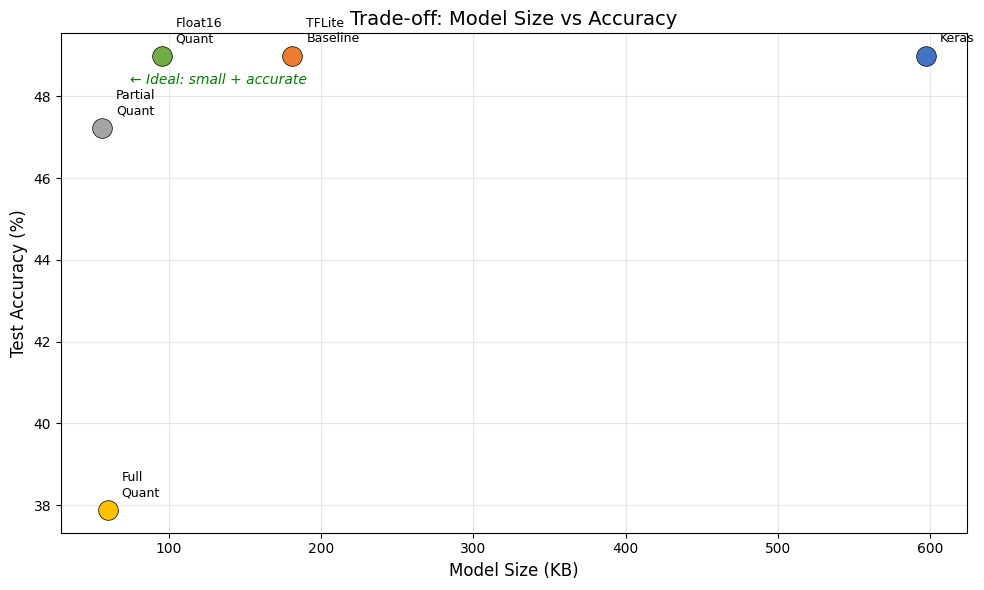

In [25]:
# scatter plot: accuracy vs model size (trade-off visualization)
fig, ax = plt.subplots(figsize=(10, 6))

all_sizes = [base_keras_size, baseline_size, partial_size, full_quant_size, fp16_size]
all_accs = [test_acc * 100, baseline_acc, partial_acc, full_acc, fp16_acc]
labels = ["Keras", "TFLite\nBaseline", "Partial\nQuant", "Full\nQuant", "Float16\nQuant"]

for x, y, label, color in zip(all_sizes, all_accs, labels, colors):
    ax.scatter(x, y, s=200, c=color, edgecolors="black", linewidth=0.5, zorder=5)
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(10, 10),
                fontsize=9, ha="left")

ax.set_xlabel("Model Size (KB)", fontsize=12)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Trade-off: Model Size vs Accuracy", fontsize=14)
ax.grid(True, alpha=0.3)

# ideal region annotation
ax.annotate("← Ideal: small + accurate", xy=(min(all_sizes), max(all_accs)),
            fontsize=10, color="green", fontstyle="italic",
            xytext=(20, -20), textcoords="offset points")

plt.tight_layout()
plt.show()

In [26]:
# download all models
files.download(BASELINE_PATH)
files.download(FULL_QUANT_PATH)
files.download(PARTIAL_PATH)
files.download(FP16_PATH)
print("\nAll models downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All models downloaded.


## Conclusions

### Size reduction

All quantization methods significantly reduced model size compared to the Keras original. Full int8 quantization achieved the greatest compression (~4×), followed by float16 (~2×) and partial quantization.

### Accuracy trade-offs

Float16 quantization preserved accuracy closest to the original model, making it the safest choice when accuracy is important. Full int8 quantization showed some accuracy loss, as expected when reducing numerical precision from 32 bits to 8 bits. Partial quantization (weights only) achieved a good balance between size reduction and accuracy preservation.

### Inference speed

All TFLite models showed dramatically faster inference compared to the Keras model, because TFLite removes training-only operations and optimizes the computation graph. The int8 models were fastest due to simpler integer arithmetic.

### Energy efficiency

Full int8 quantization is the most energy-efficient option for embedded deployment. Integer operations consume approximately 4× less energy than float32 on ARM processors, which is critical for battery-powered IoT devices.

### Recommendation

For deployment on embedded systems, the choice depends on priorities: float16 for maximum accuracy preservation, full int8 for minimum size and energy consumption, or partial quantization as a balanced middle ground. All quantized models are under 200 KB and suitable for microcontrollers.